### Model Implementation, Testing and Compression

#### logistic regression for multilinearity and random forest

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("financial_health_risk_dataset.csv")

In [3]:
df.columns

Index(['user_id', 'age', 'employment_type', 'monthly_income',
       'monthly_expenses', 'monthly_savings', 'education_loan',
       'personal_loan', 'home_loan', 'vehicle_loan', 'credit_card_due',
       'total_loans', 'investment_stocks', 'investment_crypto',
       'investment_commodities', 'investment_bonds', 'credit_score',
       'emergency_fund_months', 'debt_to_income_ratio',
       'financial_health_score', 'risk_category'],
      dtype='object')

In [4]:
data = df.drop(columns=['debt_to_income_ratio',
 'monthly_savings','total_loans','user_id','employment_type','risk_category'])

In [5]:
df.columns

Index(['user_id', 'age', 'employment_type', 'monthly_income',
       'monthly_expenses', 'monthly_savings', 'education_loan',
       'personal_loan', 'home_loan', 'vehicle_loan', 'credit_card_due',
       'total_loans', 'investment_stocks', 'investment_crypto',
       'investment_commodities', 'investment_bonds', 'credit_score',
       'emergency_fund_months', 'debt_to_income_ratio',
       'financial_health_score', 'risk_category'],
      dtype='object')

In [6]:
data.columns

Index(['age', 'monthly_income', 'monthly_expenses', 'education_loan',
       'personal_loan', 'home_loan', 'vehicle_loan', 'credit_card_due',
       'investment_stocks', 'investment_crypto', 'investment_commodities',
       'investment_bonds', 'credit_score', 'emergency_fund_months',
       'financial_health_score'],
      dtype='object')

In [7]:
print(data['financial_health_score'].value_counts())

financial_health_score
48.0    249
43.0    245
49.0    245
50.0    242
44.0    239
46.0    229
47.0    226
45.0    224
52.0    213
51.0    213
42.0    210
40.0    200
53.0    196
41.0    194
55.0    187
39.0    173
38.0    163
54.0    158
56.0    149
37.0    148
57.0    147
58.0    140
35.0    127
60.0    125
59.0    122
36.0    122
34.0    101
33.0    101
61.0     94
63.0     93
32.0     83
62.0     82
31.0     67
30.0     64
65.0     57
64.0     56
29.0     47
28.0     40
67.0     39
66.0     35
27.0     27
68.0     23
69.0     21
26.0     17
25.0     17
24.0     11
70.0     10
23.0      9
71.0      5
72.0      4
74.0      3
21.0      3
22.0      2
20.0      1
75.0      1
73.0      1
Name: count, dtype: int64


In [8]:
# Convert numeric score into 3 classes:

In [9]:
def categorize(score):
    if score >= 55:
        return "High"
    elif score >= 40:
        return "Medium"
    else:
        return "Low"

data['financial_health_category'] = data['financial_health_score'].apply(categorize)


In [10]:
data['financial_health_category'].value_counts()


financial_health_category
Medium    3283
High      1394
Low       1323
Name: count, dtype: int64

#### Logistic Regression (multilinearity)

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(data['financial_health_category'])

X = data.drop(['financial_health_score','financial_health_category'], axis=1)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [13]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, multi_class='multinomial')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


C:\Users\kumar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\kumar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
X = data.drop(['financial_health_score'], axis=1)
y = data['financial_health_category']


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)


In [16]:
X = X.select_dtypes(include=['int64', 'float64'])


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)  # increase iterations
lr.fit(X_train, y_train)


LogisticRegression(max_iter=5000)

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


Accuracy: 0.5475

Classification Report:
               precision    recall  f1-score   support

           0       0.19      0.01      0.02       279
           1       0.70      0.06      0.11       265
           2       0.55      0.97      0.70       656

    accuracy                           0.55      1200
   macro avg       0.48      0.35      0.28      1200
weighted avg       0.50      0.55      0.41      1200


Confusion Matrix:
 [[  3   0 276]
 [  2  16 247]
 [ 11   7 638]]


#### Random Forest Classifier

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


RF Accuracy: 0.8091666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.87      0.81       279
           1       0.76      0.85      0.80       265
           2       0.87      0.77      0.81       656

    accuracy                           0.81      1200
   macro avg       0.79      0.83      0.81      1200
weighted avg       0.82      0.81      0.81      1200



In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X_scaled, y, cv=5)
print("Mean CV Accuracy:", cv_scores.mean())


Mean CV Accuracy: 0.7916666666666666


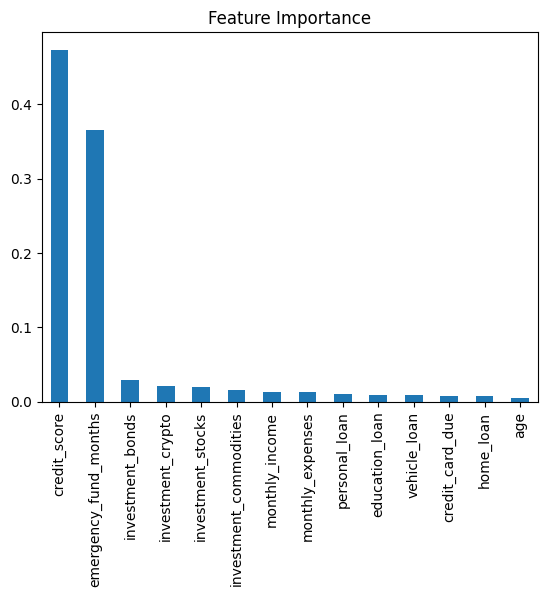

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance")
plt.show()


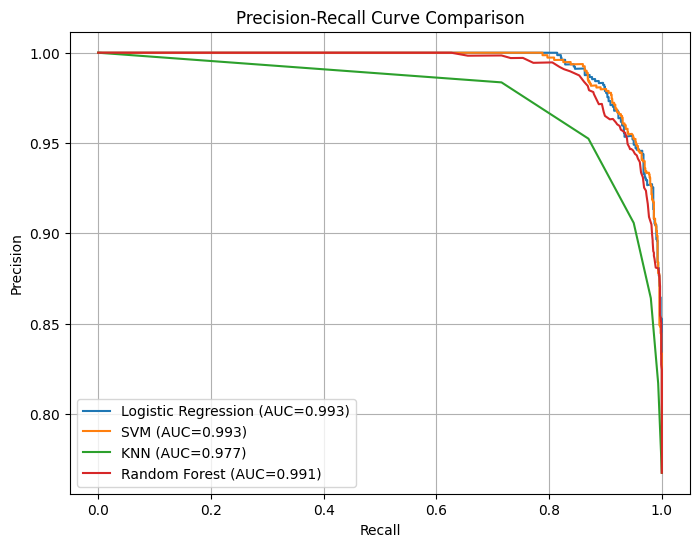

In [25]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Convert to binary
y_binary = (y >= 1).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, stratify=y_binary, random_state=42
)

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "SVM": make_pipeline(StandardScaler(), SVC(probability=True)),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "Random Forest": RandomForestClassifier()
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_scores = model.predict_proba(X_test)[:,1]

    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, label=f"{name} (AUC={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid()
plt.show()

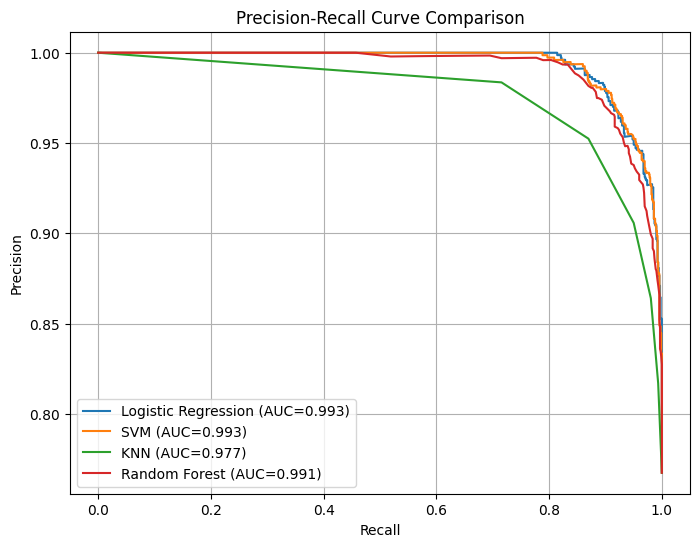

In [26]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import precision_recall_curve, auc

# =========================
# STEP 1: Convert to Binary
# =========================
# Example: Convert your target into binary (adjust if needed)
y_binary = (y >= 1).astype(int)   # 0 = Low, 1 = Medium+High

# =========================
# STEP 2: Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# =========================
# STEP 3: Define Models
# =========================
models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000)
    ),
    
    "SVM": make_pipeline(
        StandardScaler(),
        SVC(probability=True)
    ),
    
    "KNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier()
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    )
}

# =========================
# STEP 4: Plot PR Curve
# =========================
plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_scores = model.predict_proba(X_test)[:, 1]
    
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = auc(recall, precision)
    
    plt.plot(recall, precision, label=f"{name} (AUC={pr_auc:.3f})")

# =========================
# STEP 5: Styling
# =========================
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid()

# =========================
# STEP 6: Save for PPT
# =========================
plt.savefig("precision_recall_curve.png", dpi=300, bbox_inches='tight')

plt.show()